In [1]:
%matplotlib inline

import copy
import itertools
import sys
from collections import defaultdict

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import shapely.geometry as geom

sys.path.insert(0, "../")
from weavingspace import (
  KMP_Matcher,
  TileShape,
  TileUnit,
  Topology,
  Transform,
  WeaveUnit,
  tiling_utils,
  topology_plot,
)


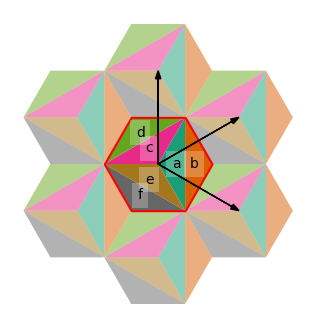

In [2]:
# tile = TileUnit(tiling_type = "cairo", n = 3)
# tile = TileUnit(tiling_type = "hex-slice", n = 6, offset = 1)
# tile = TileUnit(tiling_type = "hex-dissection", n = 9, offset = 1, offset_angle = 30)
tile = TileUnit(tiling_type = "lave", code = "3.12.12")
# tile = TileUnit(tiling_type = "archi", code = "3.3.4.3.4")
# tile = TileUnit(tiling_type = "chavey", code = "G")
# tile = TileUnit(tiling_type = "hex-colouring", n = 7)
# tile = TileUnit(tiling_type = "grid", n = 2, nrows = 1, ncols = 2, xy_offset = (0.5, 0))
# tile = tiling_utils.minimise_weave_unit(WeaveUnit(weave_type = "basket", n = 2, strands = "ab|cd"))
# tile = TileUnit(base_shape = TileShape.TRIANGLE)
tile.plot(figsize = (4, 4), r = 1, show_vectors = True).set_axis_off()

In [14]:
topo = Topology(tile, ignore_tile_ids = True)
topo._set_basis_matrix()
topo._get_coordinate_reducer()
topo._set_sentinel_points()
topo._set_symmetry_check_points()

Text(0.5, 1.0, 'In vector basis space')

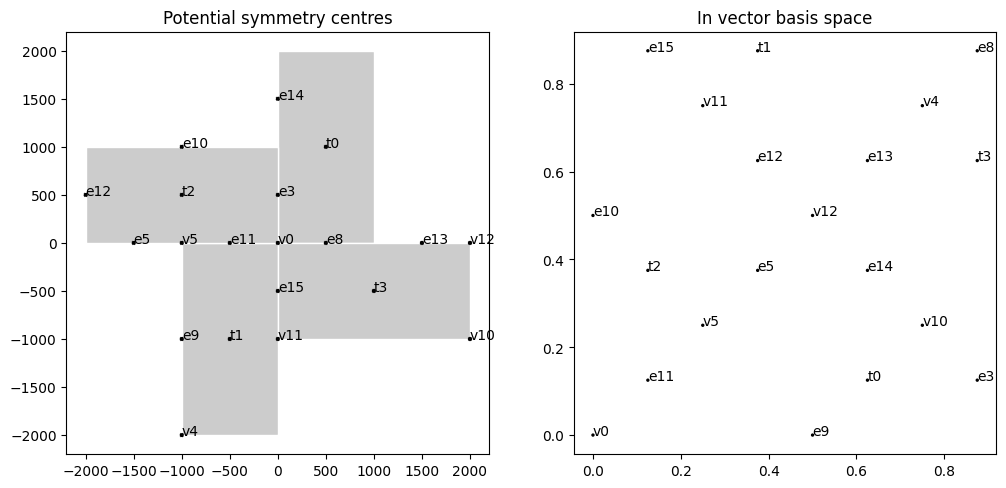

In [15]:
fig = plt.figure(figsize = (12, 6))
ax = fig.add_subplot(121)
topo.tileable.tiles.geometry.plot(ax = ax, fc = "#cccccc", ec = "w")
plt.scatter(
  [_[0] for _, ID in topo.sentinel_points], [_[1] for _, ID in topo.sentinel_points],
  sizes = [5] * len(topo.sentinel_points), color = "k", marker = "x")
for xys in topo.sentinel_points:
  ax.text(xys[0][0], xys[0][1], xys[1])
ax.set_aspect("equal")
ax.set_title("Potential symmetry centres")

ax = fig.add_subplot(122)
plt.scatter(
  [_[0] for _ in topo.check_points], [_[1] for _ in topo.check_points],
  sizes = [2] * len(topo.check_points), color = "k")
for i in range(len(topo.check_points)):
  ax.text(topo.check_points[i][0], topo.check_points[i][1], topo.sentinel_points[i][1])
ax.set_aspect("equal")
ax.set_title("In vector basis space")

In [16]:
reducer = topo._get_coordinate_reducer()
matches = {k: v[1] for k, v in zip(topo.check_points, topo.sentinel_points)}
orbits = defaultdict(set)
# rotations
for a, order in enumerate([6, 4, 3, 2]):
  angle = 2 * np.pi / order
  cos, sin = np.cos(angle), np.sin(angle)
  m = ((cos, -sin), (sin, cos))
  for centre in topo.sentinel_points:
    # Edges can only be centre of 180º rotations
    if centre[1][0] == "e" and order != 2: continue
    found = True
    targets = defaultdict(set)
    for i, pt in enumerate(topo.sentinel_points):
      px, py = pt[0][0] - centre[0][0], pt[0][1] - centre[0][1]
      pt_dash = reducer((m[0][0] * px + m[0][1] * py + centre[0][0],
                        m[1][0] * px + m[1][1] * py + centre[0][1]))
      if pt_dash in matches and pt[1][0] == matches[pt_dash][0]:
        targets[pt_dash].add((pt[1], matches[pt_dash]))
      else:
        found = False
        break
    if found:
      for k, v in targets.items():
        orbits[k] = orbits[k].union(*v)

In [17]:
# reflections can only be tiling symmetries if the mirror is parallel to the
# the translation vectors, or along or perpendicular to their angle bisector
vs = topo.tileable.get_vectors()[:2]
vs = [
  *vs, (vs[0][0] + vs[1][0], vs[0][1] + vs[1][1]),
  (vs[0][0] - vs[1][0], vs[0][1] - vs[1][1])]
directions = [np.atan2(*(v[::-1])) for v in vs]

for d, direction in enumerate(directions):
  cos, sin = np.cos(2 * direction), np.sin(2 * direction)
  m = ((cos, sin), (sin, -cos))
  for centre in topo.sentinel_points:
    found = True
    targets = defaultdict(set)
    for i, pt in enumerate(topo.sentinel_points):
      px, py = pt[0][0] - centre[0][0], pt[0][1] - centre[0][1]
      pt_dash = reducer((m[0][0] * px + m[0][1] * py + centre[0][0],
                         m[1][0] * px + m[1][1] * py + centre[0][1]))
      if pt_dash in matches and pt[1][0] == matches[pt_dash][0]:
        targets[pt_dash].add((pt[1], matches[pt_dash]))
      else:
        found = False
        break
    if found:
      for k, v in targets.items():
        orbits[k] = orbits[k].union(*v)

In [18]:
list(
  nx.connected_components(
    nx.from_edgelist(
      itertools.chain.from_iterable(
        [itertools.combinations_with_replacement(x, 2) for x in orbits.values()]
        ))))

[{'v0', 'v12'},
 {'v10', 'v11', 'v4', 'v5'},
 {'e11', 'e12', 'e13', 'e14', 'e15', 'e3', 'e5', 'e8'},
 {'e10', 'e9'},
 {'t0', 't1', 't2', 't3'}]

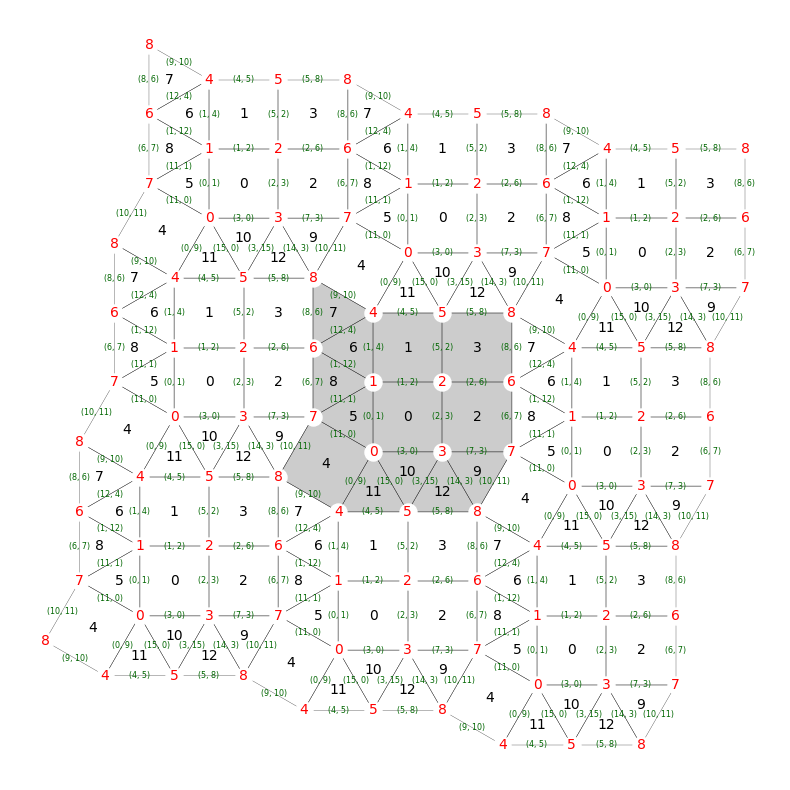

In [66]:
ax = topo.tileable.regularised_prototile.geometry.plot(fc = "#cccccc", figsize = (10, 10))

topo._get_tile_geoms().plot(ax = ax, fc = "#00000000", ec = "k", figsize = (15, 15), lw = 0.2)
topo._get_vertex_geoms().plot(ax = ax, color = "w", markersize = 150)

xy = [(t.centre.x, t.centre.y) for t in topo.tiles]
IDs = [t.base_ID for t in topo.tiles]
for xy, ID in zip(xy, IDs):
  ax.text(x = xy[0], y = xy[1], s = ID, color = "k", ha = "center", va = "center")

xy = [(v.point.x, v.point.y) for v in topo.points.values()]
IDs = [v.base_ID for v in topo.points.values()]
for xy, ID in zip(xy, IDs):
  ax.text(x = xy[0], y = xy[1], s = ID, color = "r", ha = "center", va = "center")

xy = [(e.centroid.x, e.centroid.y) for e in topo._get_edge_geoms().geometry]
IDs = [e.base_ID for e in topo.edges.values()]
for xy, ID in zip(xy, IDs):
  ax.text(x = xy[0], y = xy[1], s = ID, color = "#006600", ha = "center", va = "center", fontsize = "xx-small")

ax.set_axis_off()

IndexError: index 0 is out of bounds for axis 0 with size 0

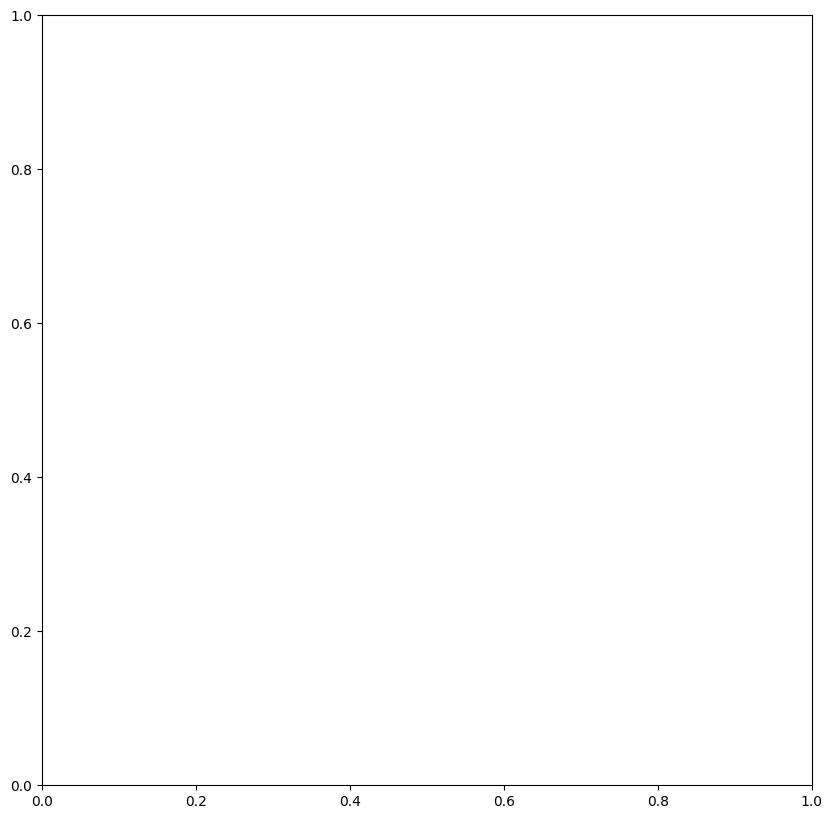

In [82]:
ax = topology_plot.plot(
  topo,
  show_original_tiles = True,
  show_tile_centres = False,
  show_vertex_labels = True,
  show_vertex_ids = False,
  show_edges = True,
  offset_edges = False,
  show_edge_labels = True,
  show_dual_tiles = False,
)

In [ ]:
s = 1000 / np.sqrt(2)
tile = TileUnit(base_shape = TileShape.RECTANGLE, spacing = 1000)
poly = geom.Polygon(
  [(0, 0), (0, s/2), (s/2, s/2), (s/2, -s/2), (-s/2, -s/2), (-s/2, 0)])
tile.tiles = gpd.GeoDataFrame(
  data = {"tile_id": ["a"]}, 
  geometry = gpd.GeoSeries([poly]),
  crs = 3857)
tile.setup_vectors((-s/2, s/2), (s, s/2))
tile.prototile = tile.get_prototile_from_vectors()
tile.regularised_prototile = copy.deepcopy(tile.tiles[["geometry"]])

## Modifying a tiling

CAUTION: new Topology will probably not be correctly labelled. To build a correct Topology, extract the tileable attribute and rebuild Topology from that.


<Axes: >

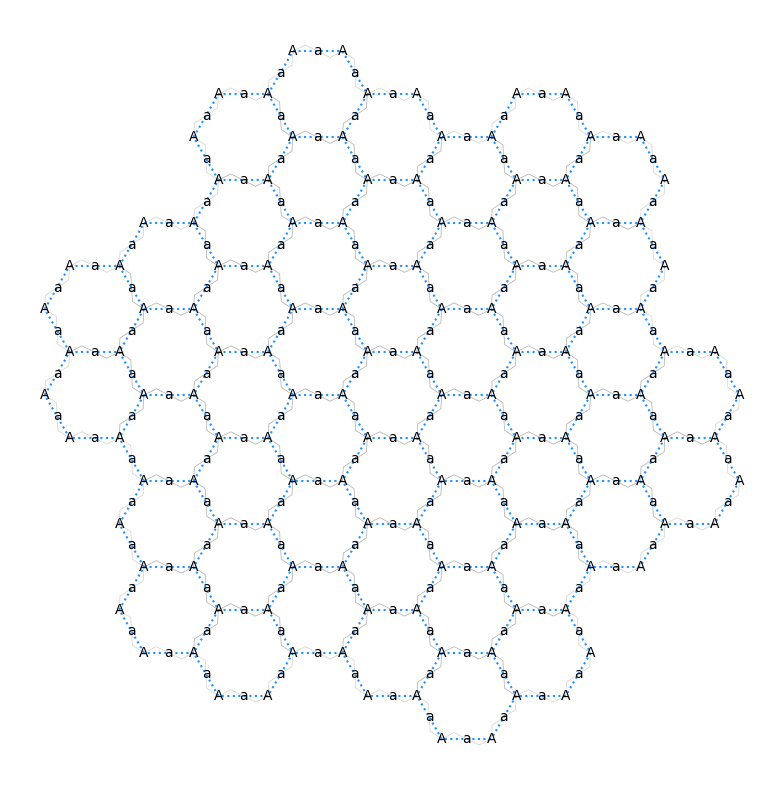

In [ ]:
topo2 = topo \
  .transform_geometry(True, True, "abcdefghijklmn", "zigzag_edge", n = 2, h = 0.25, smoothness = 0)
topology_plot.plot(
  topo2,
  show_original_tiles = True,
  show_tile_centres = False,
  show_vertex_labels = True,
  show_vertex_ids = False,
  show_edges = True,
  offset_edges = False,
  show_edge_labels = True,
  show_dual_tiles = False,
)

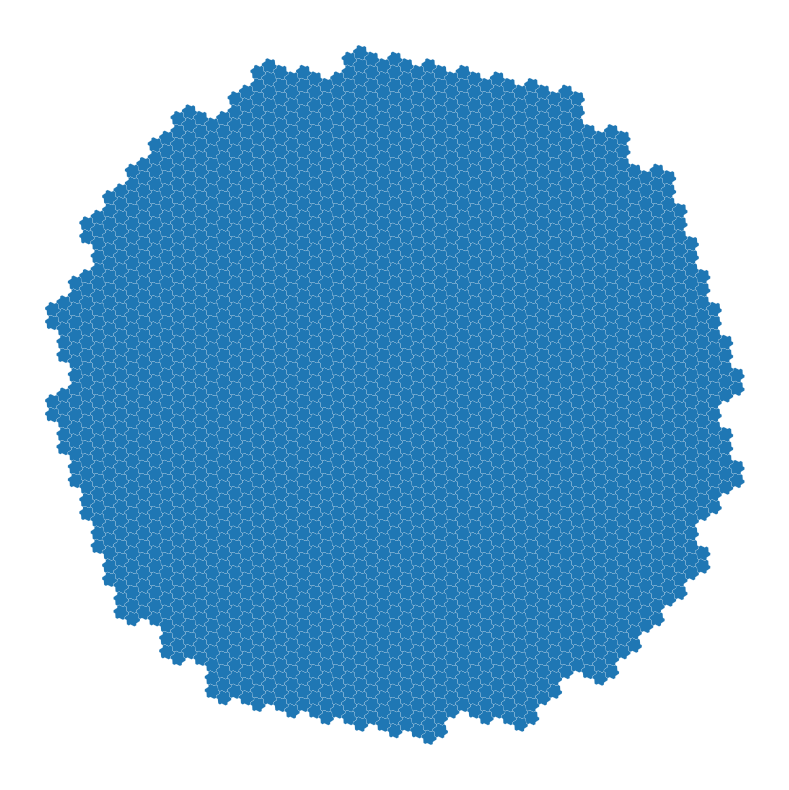

In [ ]:
from weavingspace import Tiling

d = gpd.read_file("data/imd-auckland-2018.gpkg").to_crs(topo2.tileable.crs)
tiling = Tiling(topo2.tileable, d)
tiling.tiles.plot(ec = "w", lw = 0.1, figsize = (10, 10)).set_axis_off()

Note that some tiles around the outside might not get 'deformed' correctly because they are unconstrained by neighbours (I think...), but the central tile unit should be fine. To see the potential new tiling we do this:

<Axes: >

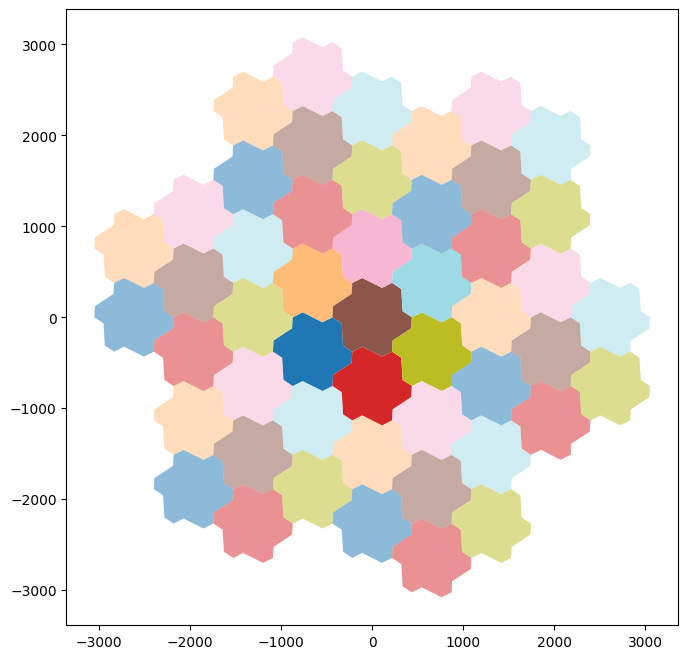

In [ ]:
tile_unit = topo2.tileable
tile_unit.plot(r = 1, show_prototile = False, show_reg_prototile = False, 
               r_alpha = 0.5, cmap = "tab20", show_ids = False)

## Tiling symmetries
As discovered in topology construction.

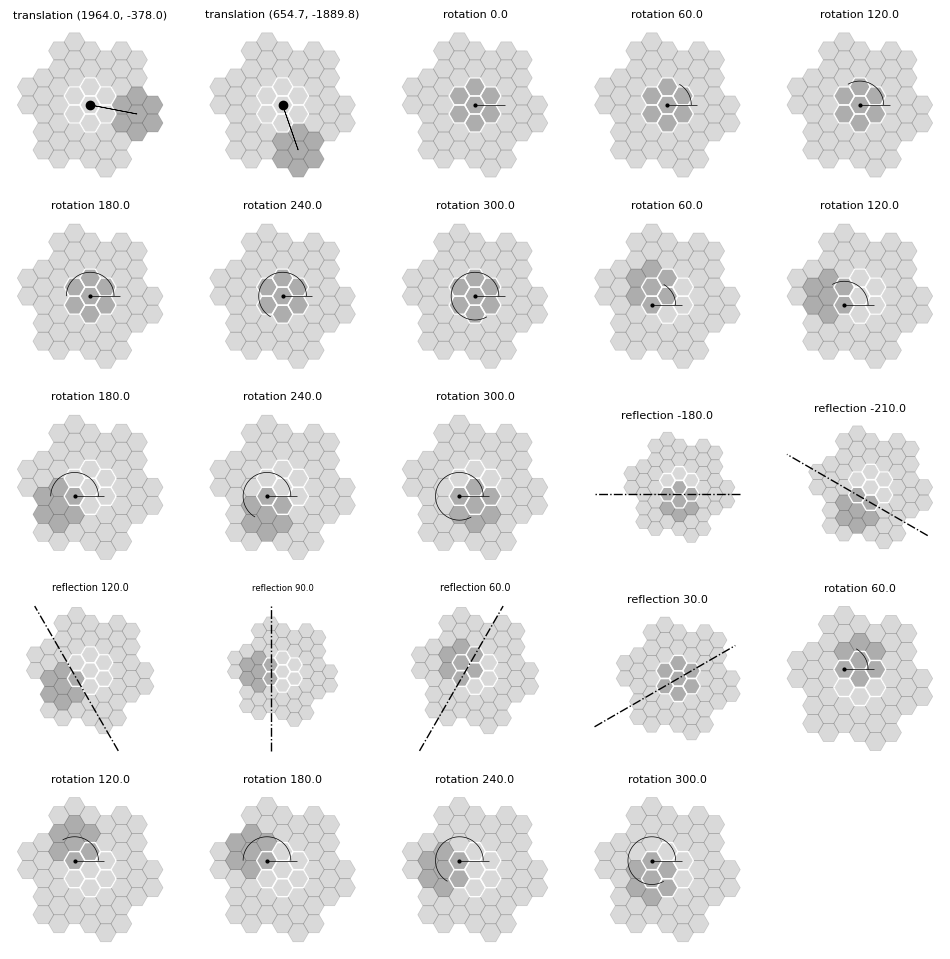

In [ ]:
topology_plot.plot_tiling_symmetries(topo, mirror_length = 8000, radius = 1000, c = geom.Point(0, 0))

## Dual tiling from the topology

In [ ]:
tile2 = copy.deepcopy(topo.tileable)
dual_tiles = list(topo.dual_tiles.values())
tile2.tiles = gpd.GeoDataFrame(
  data = {"tile_id": list("abcdefghijklmnopqrstuvwxyz")[:len(dual_tiles)]},
  geometry = gpd.GeoSeries(dual_tiles))
tile2._setup_regularised_prototile(override = True)
tile2.plot(r = 1, show_reg_prototile = True, show_prototile = False, show_vectors = False,
           cmap = "tab20", show_ids = False, figsize = (12, 12)) #, ec = "k")
